Importa as bibliotecas, carrega o arquivo e faz o tratamento inicial dos dados, incluindo ajuste de datas e criação da taxa de conversão.

In [1]:
import pandas as pd
import numpy as np
import os

# Ajuste de exibição
pd.options.display.float_format = 'R$ {:,.2f}'.format

# Lógica para encontrar o arquivo em diferentes estruturas de pastas
caminhos_possiveis = [
    "data/vendas_ecommerce.xlsx",          
    "vendas_ecommerce.xlsx",               
    "../data/vendas_ecommerce.xlsx",       
    "/home/maicongomes/Downloads/Analise_Ecommerce/data/vendas_ecommerce.xlsx" 
]

df = None
for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        print(f"✅ Arquivo encontrado em: {caminho}")
        df = pd.read_excel(caminho)
        break

if df is None:
    raise FileNotFoundError("Não foi possível encontrar o arquivo. Verifique se ele está na pasta 'data'.")

# Tratamento inicial dos dados
df.columns = df.columns.str.strip()
df['Data'] = pd.to_datetime(df['Data'])

# Criação da taxa de conversão (essencial para evitar KeyError nas próximas células)
df['conversao'] = df['N° de vendas'] / df['Qtd de acessos'].replace(0, np.nan)

df.head()

✅ Arquivo encontrado em: ../data/vendas_ecommerce.xlsx


,N° de vendas,Qtd de acessos,Data,GMV,Tipo,Parceiro,conversao
0,6,73,2019-01-01,"R$ 1,579.21",Padrão,SUBMARINO,R$ 0.08
1,11,100,2019-01-01,"R$ 3,122.76",Padrão,AMERICANAS,R$ 0.11
2,1,17,2019-01-01,R$ 249.25,Padrão,WALMART,R$ 0.06
3,1,1,2019-01-01,R$ 7.11,Padrão,GIULIANA FLORES,R$ 1.00
4,4,35,2019-01-01,"R$ 1,025.12",Padrão,DAFITI,R$ 0.11


Calcula o total de lojas únicas presentes no dataset.

In [2]:
# Quantidade total de lojas

df['Parceiro'].nunique()

621

Identifica, para cada loja, o dia em que houve maior volume de vendas.

In [3]:
# Dia com mais vendas por loja 
df.loc[df.groupby('Parceiro')['N° de vendas'].idxmax()][
    ['Parceiro', 'Data', 'N° de vendas']
]

,Parceiro,Data,N° de vendas
434,2AM GAMING,2019-01-02,1
32149,A DORA ADORA,2019-05-10,1
1401,A.BRAND,2019-01-06,1
159,AAZ PERFUMES,2019-01-01,1
4033,ABOUT HOME,2019-01-16,1
...,...,...,...
356,ÁGUA DOCE,2019-01-02,1
29453,ÉPOCA COSMÉTICOS,2019-04-30,12
269,ÓCULOS SHOP,2019-01-02,1
6886,ÓKULOS,2019-01-27,1


Filtra os dados de abril e calcula a taxa média de conversão por loja.

In [4]:
# Conversão média por loja (abril)
abril = df[df['Data'].dt.month == 4]
conversao_abril = abril.groupby('Parceiro')['conversao'].mean()

conversao_abril.map('{:.2%}'.format)

Parceiro
A.BRAND             100.00%
ABOUT HOME          100.00%
ABRAKADABRA         100.00%
ADCOS                91.67%
ADOBE                44.17%
                     ...   
ZONA CEREALISTA      73.81%
ÁGUA DOCE           100.00%
ÉPOCA COSMÉTICOS     12.39%
ÓCULOS SHOP          95.65%
ÓKULOS               96.88%
Name: conversao, Length: 485, dtype: str

Filtra os dados de maio e calcula a taxa média de conversão por loja.

In [5]:
# Conversão média por loja (maio)

maio = df[df['Data'].dt.month == 5]
conversao_maio = maio.groupby('Parceiro')['conversao'].mean()

conversao_maio.map('{:.2%}'.format)

Parceiro
A DORA ADORA        100.00%
A.BRAND             100.00%
ABOUT HOME          100.00%
ABRAKADABRA         100.00%
ADCOS               100.00%
                     ...   
ZATTINI              10.77%
ZONA CEREALISTA      75.00%
ÉPOCA COSMÉTICOS     11.19%
ÓCULOS SHOP         100.00%
ÓKULOS              100.00%
Name: conversao, Length: 440, dtype: str

Compara abril e maio para medir a variação percentual da conversão entre os meses.

In [6]:
# Variação de conversão entre Abril e Maio

conv_abril = df[df['Data'].dt.month == 4].groupby('Parceiro')['conversao'].mean()
conv_maio = df[df['Data'].dt.month == 5].groupby('Parceiro')['conversao'].mean()

variacao = ((conv_maio - conv_abril) / conv_abril) * 100
print("Variação percentual por parceiro:")
print(variacao)

Variação percentual por parceiro:
Parceiro
A DORA ADORA            NaN
A.BRAND             R$ 0.00
ABOUT HOME          R$ 0.00
ABRAKADABRA         R$ 0.00
ADCOS               R$ 9.09
                     ...   
ZONA CEREALISTA     R$ 1.61
ÁGUA DOCE               NaN
ÉPOCA COSMÉTICOS   R$ -9.68
ÓCULOS SHOP         R$ 4.55
ÓKULOS              R$ 3.23
Name: conversao, Length: 511, dtype: float64


Agrupa os dados por mês e calcula o valor total de vendas (GMV) em cada período.

In [7]:
# GMV total por mês 

df['mes'] = df['Data'].dt.strftime('%b/%Y')
df.groupby('mes')['GMV'].sum()

mes
Apr/2019   R$ 4,294,167.73
Feb/2019   R$ 3,476,037.69
Jan/2019   R$ 3,913,207.47
Mar/2019   R$ 4,652,309.13
May/2019   R$ 2,317,124.98
Name: GMV, dtype: float64

Filtra um intervalo de datas e calcula o GMV total dentro desse período.

In [8]:
# GMV acumulado (18/02 a 20/04)

acumulado = df[(df['Data'] >= '2019-02-18') & (df['Data'] <= '2019-04-20')]['GMV'].sum()
print(f"O GMV acumulado no período de 18/02 a 20/04 foi de: R$ {acumulado:,.2f}")

O GMV acumulado no período de 18/02 a 20/04 foi de: R$ 8,984,946.86


Seleciona vendas promocionais e mostra as 10 lojas com maior GMV nesse contexto.

In [9]:
# Lojas com vendas promocionais

promo_gmv = df[df['Tipo'] == 'Promocional'].groupby('Parceiro')['GMV'].sum().sort_values(ascending=False)
print("Top 10 Lojas com Maior GMV Promocional:")
promo_gmv.head(10)

Top 10 Lojas com Maior GMV Promocional:


Parceiro
SUBMARINO    R$ 273,380.75
AMERICANAS   R$ 261,834.79
ALIEXPRESS   R$ 185,150.55
SHOPTIME      R$ 47,621.70
NETSHOES      R$ 46,634.23
Name: GMV, dtype: float64

Apresenta o total de vendas promocionais para todas as lojas, ordenado do maior para o menor.

In [10]:
# GMV por loja no promocional

promo_gmv = df[df['Tipo'] == 'Promocional'].groupby('Parceiro')['GMV'].sum().sort_values(ascending=False)
promo_gmv

Parceiro
SUBMARINO    R$ 273,380.75
AMERICANAS   R$ 261,834.79
ALIEXPRESS   R$ 185,150.55
SHOPTIME      R$ 47,621.70
NETSHOES      R$ 46,634.23
Name: GMV, dtype: float64

Identifica as datas de início e fim das campanhas promocionais.

In [11]:
# Período das promoções

promo = df[df['Tipo'] == 'Promocional']
print(f"A promoção começou em: {promo['Data'].min()}")
print(f"A promoção terminou em: {promo['Data'].max()}")

A promoção começou em: 2019-03-20 00:00:00
A promoção terminou em: 2019-03-31 00:00:00


Calcula o GMV total por loja e destaca as que mais faturaram.

In [12]:
# Insigth (loja que mais vendeu)

df.groupby('Parceiro')['GMV'].sum().sort_values(ascending=False)

Parceiro
AMERICANAS       R$ 2,862,704.11
SUBMARINO        R$ 2,280,551.58
ALIEXPRESS       R$ 1,685,509.18
AMAZON           R$ 1,341,817.59
SHOPTIME           R$ 824,645.34
                       ...      
LOJA INTEGRADA           R$ 0.00
INSTACARRO               R$ 0.00
UNIDAS LOCAÇÃO           R$ 0.00
UBER                     R$ 0.00
AIRBNB                   R$ 0.00
Name: GMV, Length: 621, dtype: float64

Encontra o dia com maior volume de vendas considerando todo o dataset.

In [13]:
# Loja que mais vendeu (GMV acumulado)
display(df.groupby('Parceiro')['GMV'].sum().sort_values(ascending=False).head(5))

# Melhor dia de venda (Recorde de GMV único)
print("\nMelhor dia de venda registrado:")
display(df.loc[df['GMV'].idxmax()])

Parceiro
AMERICANAS   R$ 2,862,704.11
SUBMARINO    R$ 2,280,551.58
ALIEXPRESS   R$ 1,685,509.18
AMAZON       R$ 1,341,817.59
SHOPTIME       R$ 824,645.34
Name: GMV, dtype: float64


Melhor dia de venda registrado:


N° de vendas                      114
Qtd de acessos                    740
Data              2019-03-14 00:00:00
GMV                     R$ 142,970.36
Tipo                           Padrão
Parceiro                    SUBMARINO
conversao                     R$ 0.15
mes                          Mar/2019
Name: 18336, dtype: object

Calcula a taxa média de conversão considerando todos os dados.

In [14]:
# Taxa de conversão média considerando todo o dataset

media_conversao = df['conversao'].mean()
print(f"A taxa de conversão média geral é de: {media_conversao:.2%}")

A taxa de conversão média geral é de: 63.86%


Gera um gráfico mostrando a evolução das vendas ao longo do tempo.

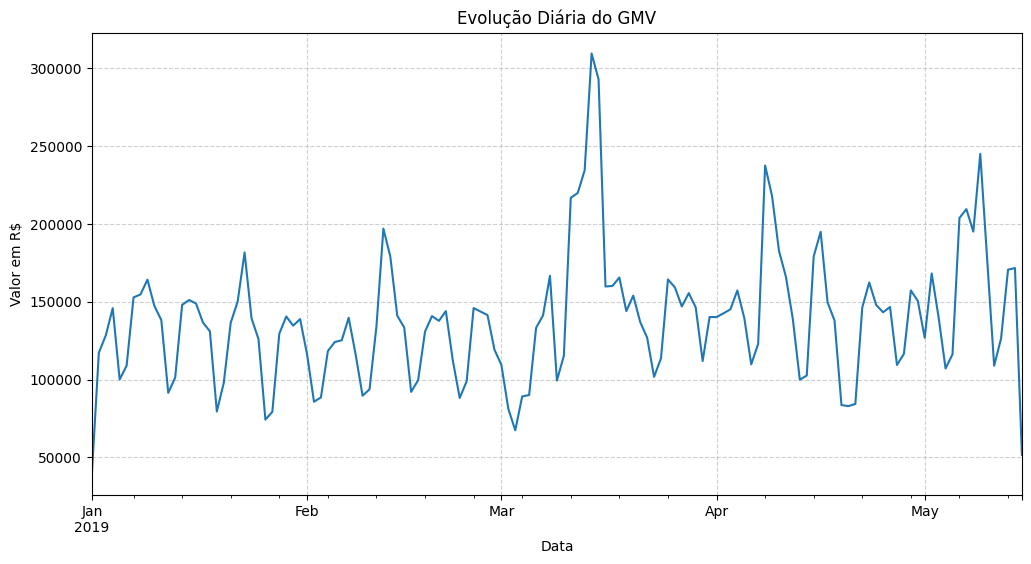

In [15]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 6))
df.groupby('Data')['GMV'].sum().plot(kind='line', title='Evolução Diária do GMV', color='#1f77b4')
plt.ylabel('Valor em R$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Consolida os principais indicadores de desempenho, incluindo vendas totais, conversão e destaque de lojas.

In [16]:
# 1. Métricas Gerais
total_gmv = df['GMV'].sum()
ticket_medio = total_gmv / df['N° de vendas'].sum()
conv_geral = df['conversao'].mean()

# 2. Performance de Lojas (Top 5)
top_lojas = df.groupby('Parceiro')['GMV'].sum().sort_values(ascending=False).head(5)

# 3. Resumo da Promoção
promo_df = df[df['Tipo'] == 'Promocional']
inicio_promo = promo_df['Data'].min()
fim_promo = promo_df['Data'].max()
gmv_promo = promo_df['GMV'].sum()

# --- EXIBIÇÃO FORMATADA ---
print(f"{' RELATÓRIO DE PERFORMANCE ':=^40}")
print(f"GMV Total Acumulado: R$ {total_gmv:,.2f}")
print(f"Ticket Médio Geral:  R$ {ticket_medio:,.2f}")
print(f"Taxa de Conversão Média: {conv_geral:.2%}")
print("-" * 40)
print(f"Período Promocional: {inicio_promo.date()} até {fim_promo.date()}")
print(f"GMV Gerado em Promoção: R$ {gmv_promo:,.2f}")
print("-" * 40)
print("Top 5 Parceiros por Faturamento:")
print(top_lojas)
print("=" * 40)

======= RELATÓRIO DE PERFORMANCE =======
GMV Total Acumulado: R$ 18,652,847.01
Ticket Médio Geral:  R$ 260.01
Taxa de Conversão Média: 63.86%
----------------------------------------
Período Promocional: 2019-03-20 até 2019-03-31
GMV Gerado em Promoção: R$ 814,622.03
----------------------------------------
Top 5 Parceiros por Faturamento:
Parceiro
AMERICANAS   R$ 2,862,704.11
SUBMARINO    R$ 2,280,551.58
ALIEXPRESS   R$ 1,685,509.18
AMAZON       R$ 1,341,817.59
SHOPTIME       R$ 824,645.34
Name: GMV, dtype: float64
